# Preprocessing and Data Pipeline

This notebook drives `src/data_loader.py`. It produces three artefacts the modelling notebooks consume:

1. A resplit manifest that fixes the unusably small original validation set (16 images).
2. A `tf.data.Dataset` pipeline for train, val, and test, with augmentation on train only.
3. Class weights for the loss function, to counter the train-set imbalance.

Decisions worth noting:
- All images are resized to 224x224 to match DenseNet121's pretrained input.
- Grayscale X-rays are forced to 3 channels because DenseNet's pretrained weights expect 3.
- Normalisation uses `tf.keras.applications.densenet.preprocess_input` so the input distribution matches what DenseNet was trained on.
- Augmentation is intentionally mild (no vertical flip, small rotation, mild contrast). Medical images have a meaningful orientation, and aggressive transforms risk creating anatomically implausible inputs.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from src.data_loader import build_datasets, IMG_SIZE, BATCH_SIZE

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.16.1
GPU available: False


## 1. Build the datasets

In [2]:
DATA_DIR = PROJECT_ROOT / "chest_xray"
train_ds, val_ds, test_ds, class_weights, manifest = build_datasets(DATA_DIR)

print("Class weights:", class_weights)
print("Image size:", IMG_SIZE, "  batch:", BATCH_SIZE)

Class weights: {0: 1.944490472245236, 1: 0.6730714080871809}
Image size: (224, 224)   batch: 32


In [3]:
split_summary = manifest.groupby(["split", "label"]).size().unstack(fill_value=0)
split_summary["total"] = split_summary.sum(axis=1)
split_summary

label,NORMAL,PNEUMONIA,total
split,,,
test,234,390,624
train,1207,3487,4694
val,142,396,538


The validation split is now around 530 images (10 percent of train plus the original 16) which is large enough to give stable epoch-to-epoch metrics during training.

## 2. Sanity check a single batch

Pull one batch from `train_ds` and verify shape, dtype, label balance, and that augmentation is producing visible variation.

In [4]:
for images, labels in train_ds.take(1):
    print("images shape:", images.shape, "dtype:", images.dtype)
    print("labels shape:", labels.shape, "dtype:", labels.dtype)
    print("label balance in batch:", dict(zip(*np.unique(labels.numpy(), return_counts=True))))
    print("value range (post-preprocess):", float(images.numpy().min()), "to", float(images.numpy().max()))
    batch_imgs, batch_labels = images.numpy(), labels.numpy()
    break

images shape: (32, 224, 224, 3) dtype: <dtype: 'float32'>
labels shape: (32,) dtype: <dtype: 'float32'>
label balance in batch: {0.0: 11, 1.0: 21}
value range (post-preprocess): 0.0 to 2.7224996089935303


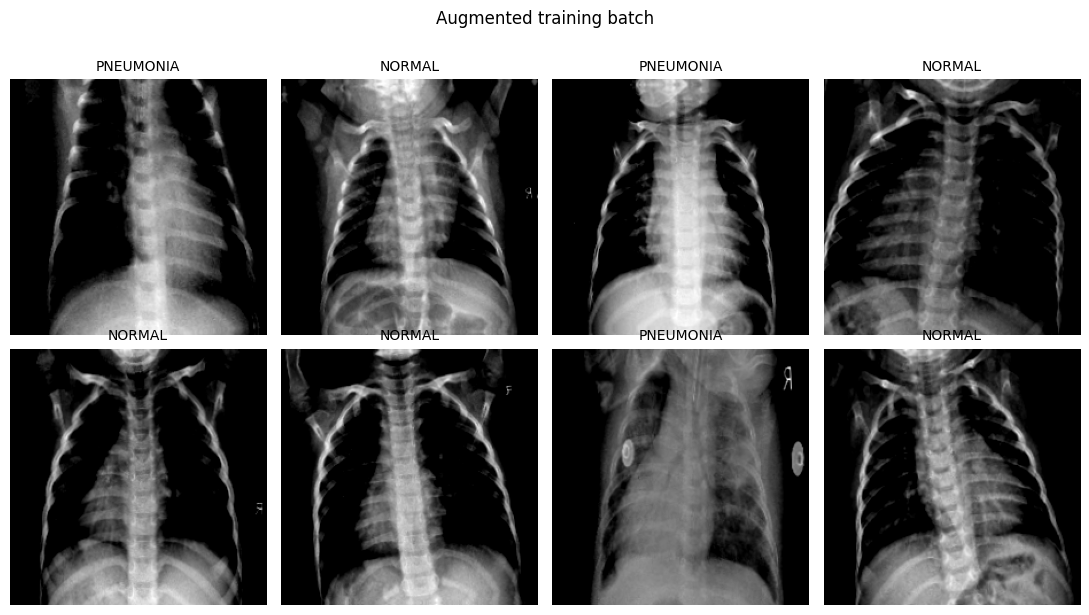

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for ax, img, lab in zip(axes.flat, batch_imgs[:8], batch_labels[:8]):
    rescaled = (img - img.min()) / (img.max() - img.min() + 1e-8)
    ax.imshow(rescaled[..., 0], cmap="gray")
    ax.set_title("PNEUMONIA" if lab == 1 else "NORMAL", fontsize=10)
    ax.axis("off")
fig.suptitle("Augmented training batch", y=1.02)
fig.tight_layout()
(PROJECT_ROOT / "reports" / "figures").mkdir(parents=True, exist_ok=True)
fig.savefig(PROJECT_ROOT / "reports" / "figures" / "augmented_batch.png", bbox_inches="tight")
plt.show()

## 3. Persist preprocessing metadata

The Streamlit app and the evaluation notebook both need to know the class index mapping and the class weights used during training.

In [6]:
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)

(models_dir / "class_indices.json").write_text(json.dumps({"NORMAL": 0, "PNEUMONIA": 1}, indent=2))
(PROJECT_ROOT / "reports" / "class_weights.json").write_text(json.dumps(class_weights, indent=2))

manifest_out = PROJECT_ROOT / "reports" / "manifest_resplit.csv"
manifest.to_csv(manifest_out, index=False)
print("Saved:")
print(" -", models_dir / "class_indices.json")
print(" -", PROJECT_ROOT / "reports" / "class_weights.json")
print(" -", manifest_out)

Saved:
 - D:\ZE5 PORTOFOLIO DS\Medical diagnosis with deep lerning\models\class_indices.json
 - D:\ZE5 PORTOFOLIO DS\Medical diagnosis with deep lerning\reports\class_weights.json
 - D:\ZE5 PORTOFOLIO DS\Medical diagnosis with deep lerning\reports\manifest_resplit.csv


## Summary

- Resplit gives a usable validation set.
- Pipeline outputs DenseNet-ready 224x224x3 float tensors with augmentation only on train.
- Class weights are saved for use during training.

Next: `03_baseline_cnn.ipynb` trains a small custom CNN as a reference point, and `04_transfer_learning.ipynb` trains the main DenseNet121 model.